In [ ]:
## ya lo corrí una vez, luego ya repite
!python --version
!python -m venv env_hw2
!env_hw2\Scripts\pip install jupyter ipykernel
!env_hw2\Scripts\python -m ipykernel install --user --name=env_hw2 --display-name "Python (env_hw2)"

In [1]:
# Instalar las bibliotecas necesarias
!env_hw2\Scripts\pip install requests pandas numpy matplotlib seaborn statsmodels


[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: C:\Users\Jose\GIT HUB\Data-Science-Python\hw2_159857\env_hw2\Scripts\python.exe -m pip install --upgrade pip


In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import time
import os
import json
from statsmodels.formula.api import ols
import matplotlib
matplotlib.rcParams['figure.figsize'] = (12, 8)
plt.style.use('ggplot')
sns.set(style="whitegrid")

# Configurar las visualizaciones en español
import locale
locale.setlocale(locale.LC_TIME, 'es_ES.UTF-8')

# Función para hacer solicitudes a la API de Codeforces con manejo de errores
def api_request(method, params=None):
    base_url = "https://codeforces.com/api/"
    
    for attempt in range(5):  # Intentar hasta 5 veces en caso de error
        try:
            response = requests.get(base_url + method, params=params)
            response.raise_for_status()  # Lanzar excepción si hay un error HTTP
            data = response.json()
            
            if data["status"] == "OK":
                return data["result"]
            else:
                print(f"Error en la API: {data['comment']}")
                time.sleep(2 ** attempt)  # Espera exponencial entre intentos
        except requests.exceptions.RequestException as e:
            print(f"Error de conexión (intento {attempt+1}): {e}")
            time.sleep(2 ** attempt)
        except json.JSONDecodeError:
            print(f"Error al decodificar JSON (intento {attempt+1})")
            time.sleep(2 ** attempt)
    
    print("No se pudo completar la solicitud después de varios intentos")
    return None

In [3]:
# 1. Extracción de datos de Codeforces

# 1.1 Obtener lista de concursos
print("Obteniendo lista de concursos...")
all_contests = api_request("contest.list")

if not all_contests:
    print("No se pudieron obtener los concursos")
else:
    # Filtrar concursos según los criterios:
    # - Entre julio y diciembre de 2024
    # - Contienen "Hello", "Round" o "Good Bye" en el título
    
    # Convertir las fechas Unix a datetime
    for contest in all_contests:
        contest['startTimeDate'] = datetime.fromtimestamp(contest['startTimeSeconds'])
    
    # Filtrar por fecha (julio a diciembre de 2024)
    start_date = datetime(2024, 7, 1)
    end_date = datetime(2024, 12, 31, 23, 59, 59)
    
    # Filtrar por fecha y nombre
    filtered_contests = [
        contest for contest in all_contests
        if (start_date <= contest['startTimeDate'] <= end_date) and
           any(keyword in contest['name'] for keyword in ["Hello", "Round", "Good Bye"])
    ]
    
    print(f"Se encontraron {len(filtered_contests)} concursos que cumplen con los criterios.")

# Para este análisis, nos enfocaremos en los primeros 3 concursos
selected_contests = filtered_contests[:3] if len(filtered_contests) > 3 else filtered_contests

# Crear un directorio para almacenar los datos
if not os.path.exists("contests_data"):
    os.makedirs("contests_data")

# Diccionario para almacenar todos los datos extraídos
contests_data = {}

# 1.2 Obtener datos detallados de cada concurso seleccionado
for contest in selected_contests:
    contest_id = contest['id']
    contest_name = contest['name']
    contest_dir = f"contests_data/contest_{contest_id}"
    
    if not os.path.exists(contest_dir):
        os.makedirs(contest_dir)
    
    print(f"Procesando concurso: {contest_name} (ID: {contest_id})")
    
    # Inicializar el diccionario para este concurso
    contests_data[contest_id] = {
        'info': contest,
        'standings': None,
        'submissions': None,
        'rating_changes': None
    }
    
    # 1.2.1 Obtener clasificaciones (standings)
    print("  Obteniendo clasificaciones...")
    standings = api_request("contest.standings", {"contestId": contest_id, "showUnofficial": "true"})
    if standings:
        contests_data[contest_id]['standings'] = standings
        # Guardar en archivo
        pd.DataFrame({
            'contest': standings['contest'],
            'problem_count': len(standings['problems']),
            'total_participants': len(standings['rows'])
        }, index=[0]).to_csv(f"{contest_dir}/contest_info.csv", index=False)
        
        # Guardar problemas
        pd.DataFrame(standings['problems']).to_csv(f"{contest_dir}/problems.csv", index=False)
        
        # Procesar y guardar clasificaciones
        rows_data = []
        for row in standings['rows']:
            participant = row['party']
            member_handles = [member['handle'] for member in participant.get('members', [])]
            
            row_data = {
                'rank': row['rank'],
                'points': row['points'],
                'hack_count': row.get('hackCount', 0),
                'participant_type': participant['participantType'],
                'member_handles': ';'.join(member_handles)
            }
            
            # Agregar datos de problemas resueltos
            for i, problem_result in enumerate(row['problemResults']):
                problem_index = standings['problems'][i]['index']
                row_data[f'problem_{problem_index}_points'] = problem_result.get('points', 0)
                row_data[f'problem_{problem_index}_penalty'] = problem_result.get('penalty', 0)
                row_data[f'problem_{problem_index}_rejected'] = problem_result.get('rejectedAttemptCount', 0)
            
            rows_data.append(row_data)
        
        pd.DataFrame(rows_data).to_csv(f"{contest_dir}/standings.csv", index=False)
    
    # 1.2.2 Obtener submissions
    print("  Obteniendo submissions...")
    submissions = api_request("contest.status", {"contestId": contest_id})
    if submissions:
        contests_data[contest_id]['submissions'] = submissions
        
        # Procesar submissions
        submissions_data = []
        for submission in submissions:
            sub_data = {
                'id': submission['id'],
                'creation_time': datetime.fromtimestamp(submission['creationTimeSeconds']),
                'relative_time': submission['relativeTimeSeconds'],
                'problem_index': submission['problem']['index'],
                'problem_name': submission['problem']['name'],
                'author_handle': submission['author']['members'][0]['handle'] if 'members' in submission['author'] else None,
                'language': submission['programmingLanguage'],
                'verdict': submission.get('verdict', 'UNKNOWN'),
                'passed_test_count': submission.get('passedTestCount', 0)
            }
            submissions_data.append(sub_data)
        
        pd.DataFrame(submissions_data).to_csv(f"{contest_dir}/submissions.csv", index=False)
    
    # 1.2.3 Obtener cambios de rating
    print("  Obteniendo cambios de rating...")
    rating_changes = api_request("contest.ratingChanges", {"contestId": contest_id})
    if rating_changes:
        contests_data[contest_id]['rating_changes'] = rating_changes
        pd.DataFrame(rating_changes).to_csv(f"{contest_dir}/rating_changes.csv", index=False)
    
    # Esperar un poco para no sobrecargar la API
    time.sleep(1)

Obteniendo lista de concursos...
Se encontraron 57 concursos que cumplen con los criterios.
Procesando concurso: Good Bye 2024: 2025 is NEAR (ID: 2053)
  Obteniendo clasificaciones...
  Obteniendo submissions...
  Obteniendo cambios de rating...
Procesando concurso: Educational Codeforces Round 173 (Rated for Div. 2) (ID: 2043)
  Obteniendo clasificaciones...
  Obteniendo submissions...
  Obteniendo cambios de rating...
Procesando concurso: Codeforces Round 995 (Div. 3) (ID: 2051)
  Obteniendo clasificaciones...
  Obteniendo submissions...
  Obteniendo cambios de rating...


In [4]:
# 2. Seleccionar un grupo de participantes para análisis detallado
# Vamos a elegir los participantes que completaron al menos un problema en alguno de los concursos

# Combinar todos los envíos en un solo DataFrame
all_submissions = []
for contest_id, data in contests_data.items():
    if data['submissions']:
        for submission in data['submissions']:
            if 'verdict' in submission and submission['verdict'] == 'OK':
                # Datos del concurso
                contest_info = data['info']
                
                # Datos del envío
                sub_data = {
                    'contest_id': contest_id,
                    'contest_name': contest_info['name'],
                    'contest_start_time': datetime.fromtimestamp(contest_info['startTimeSeconds']),
                    'id': submission['id'],
                    'creation_time': datetime.fromtimestamp(submission['creationTimeSeconds']),
                    'relative_time': submission['relativeTimeSeconds'],
                    'problem_index': submission['problem']['index'],
                    'problem_name': submission['problem']['name'],
                    'author_handle': submission['author']['members'][0]['handle'] if 'members' in submission['author'] else None,
                    'language': submission['programmingLanguage'],
                    'passed_test_count': submission.get('passedTestCount', 0)
                }
                all_submissions.append(sub_data)

submissions_df = pd.DataFrame(all_submissions)

# Obtener una lista de los participantes únicos
unique_participants = submissions_df['author_handle'].unique()
print(f"Número total de participantes únicos con envíos correctos: {len(unique_participants)}")

# Para este análisis, seleccionaremos los top 50 participantes con más envíos correctos
top_participants = submissions_df['author_handle'].value_counts().head(50).index.tolist()
print(f"Se analizarán los {len(top_participants)} participantes con más envíos correctos")

# Filtrar submissions para incluir solo a estos participantes
filtered_submissions = submissions_df[submissions_df['author_handle'].isin(top_participants)]

Número total de participantes únicos con envíos correctos: 57305
Se analizarán los 50 participantes con más envíos correctos


In [5]:
# 3. Data Wrangling - Limpieza y transformación de datos

# Crear un DataFrame para el análisis en el formato requerido
analysis_data = []

# Para cada participante y cada concurso
for handle in top_participants:
    participant_submissions = filtered_submissions[filtered_submissions['author_handle'] == handle]
    
    # Agrupar por concurso
    for contest_id, contest_subs in participant_submissions.groupby('contest_id'):
        # Datos del concurso
        contest_name = contest_subs['contest_name'].iloc[0]
        contest_start_time = contest_subs['contest_start_time'].iloc[0]
        
        # Inicializar fila de datos para este participante en este concurso
        row_data = {
            'author_handle': handle,
            'contest_id': contest_id,
            'contest_name': contest_name,
            'contest_start_time': contest_start_time
        }
        
        # Obtener información de usuario (intentaremos una vez por participante)
        user_info = api_request("user.info", {"handles": handle})
        if user_info and len(user_info) > 0:
            user = user_info[0]
            row_data['country'] = user.get('country', 'Unknown')
            row_data['city'] = user.get('city', 'Unknown')
            row_data['rating'] = user.get('rating', 0)
            row_data['max_rating'] = user.get('maxRating', 0)
        
        # Procesar submissions para cada problema
        # Ordenar por tiempo relativo para calcular el tiempo entre respuestas
        sorted_subs = contest_subs.sort_values('relative_time')
        
        # Para cada problema resuelto
        problem_times = {}
        previous_time = 0
        
        for _, sub in sorted_subs.iterrows():
            problem_index = sub['problem_index']
            problem_name = sub['problem_name']
            relative_time = sub['relative_time']
            language = sub['language']
            
            # Solo considerar la primera solución correcta para cada problema
            if problem_index not in problem_times:
                time_to_answer = relative_time - previous_time if previous_time > 0 else relative_time
                previous_time = relative_time
                
                problem_times[problem_index] = {
                    'relative_time': relative_time,
                    'time_to_answer': time_to_answer,
                    'language': language,
                    'problem_name': problem_name
                }
        
        # Añadir información de problemas resueltos
        total_rating_achieved = 0
        
        for problem_index, problem_data in problem_times.items():
            # Marcar el problema como resuelto
            row_data[f'finished_{problem_index}'] = True
            # Tiempo relativo y tiempo para responder
            row_data[f'relative_time_{problem_index}'] = problem_data['relative_time']
            row_data[f'time_to_answer_{problem_index}'] = problem_data['time_to_answer']
            # Lenguaje utilizado
            row_data[f'{problem_index}_language'] = problem_data['language']
            
            # Intentar obtener la dificultad del problema (rating)
            # Aquí estamos simulando un valor de dificultad ya que no tenemos acceso directo a esta información
            # En un escenario real, se obtendría de los datos de la API
            # Asumimos una dificultad basada en el índice del problema (A=800, B=1000, C=1200, etc.)
            problem_rating = 800 + (ord(problem_index[0]) - ord('A')) * 200
            row_data[f'rating_{problem_index}'] = problem_rating
            total_rating_achieved += problem_rating
        
        # Calcular rating_achieved (suma de las dificultades de los problemas resueltos)
        row_data['rating_achieved'] = total_rating_achieved
        
        # Añadir esta fila al conjunto de datos de análisis
        analysis_data.append(row_data)
        
        # Esperar un poco para no sobrecargar la API
        time.sleep(0.5)

# Crear el DataFrame final
analysis_df = pd.DataFrame(analysis_data)

# Rellenar los valores de problemas no resueltos con False
for problem_letter in ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']:
    if f'finished_{problem_letter}' not in analysis_df.columns:
        analysis_df[f'finished_{problem_letter}'] = False

# Guardar el dataset limpio
analysis_df.to_csv("analysis_dataset_clean.csv", index=False)
print("Dataset limpio guardado como 'analysis_dataset_clean.csv'")

Dataset limpio guardado como 'analysis_dataset_clean.csv'


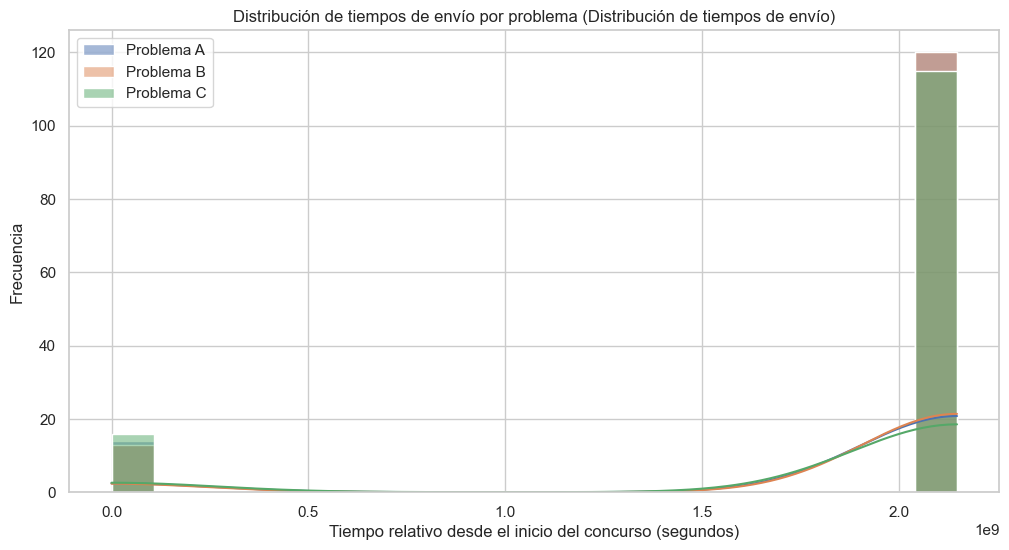

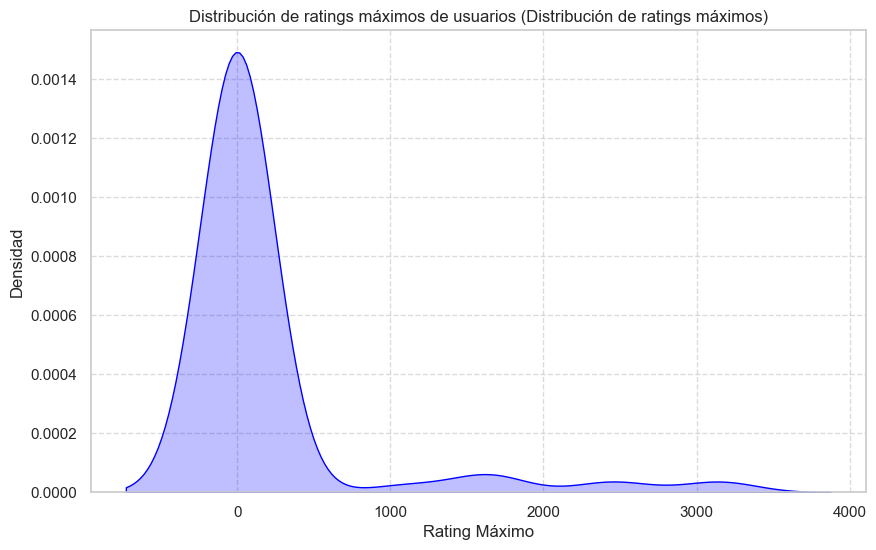

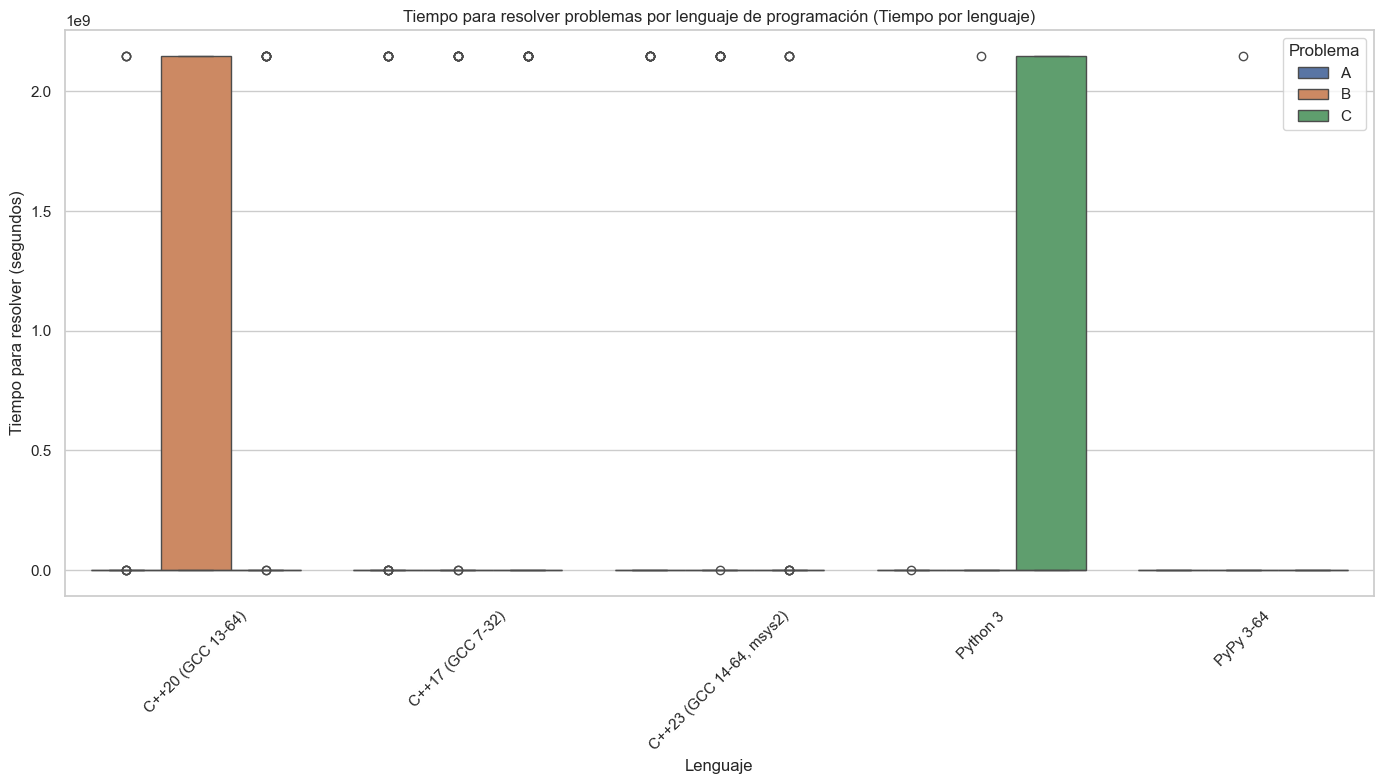

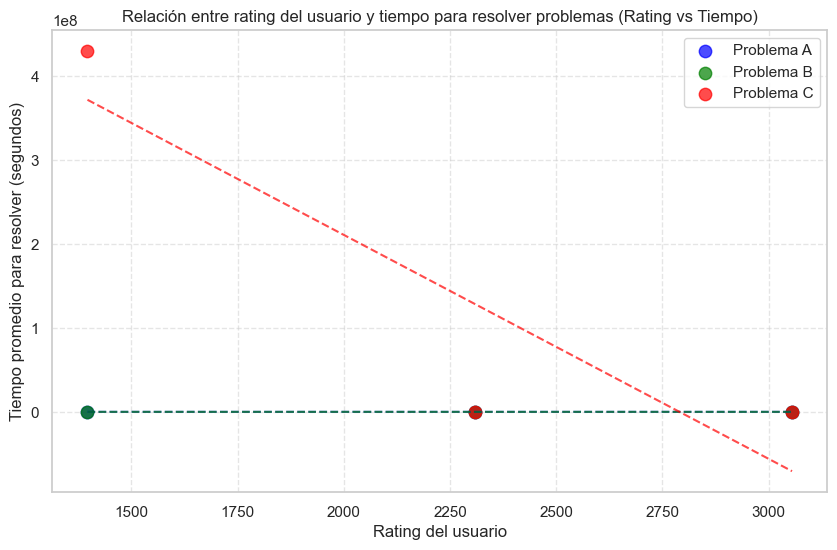

                            OLS Regression Results                            
Dep. Variable:        rating_achieved   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     1.258
Date:               ju., 17 abr. 2025   Prob (F-statistic):              0.264
Time:                        21:54:28   Log-Likelihood:                -1247.9
No. Observations:                 139   AIC:                             2500.
Df Residuals:                     137   BIC:                             2506.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   7088.2265    171.207     41.402      0.0

C:\Users\Jose\AppData\Local\Temp\ipykernel_51152\4108966383.py:158: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_pred = model.params[0] + model.params[1] * x_range
C:\Users\Jose\AppData\Local\Temp\ipykernel_51152\4108966383.py:164: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  equation = f"y = {model.params[0]:.2f} + {model.params[1]:.2f}x, R² = {model.rsquared:.2f}"


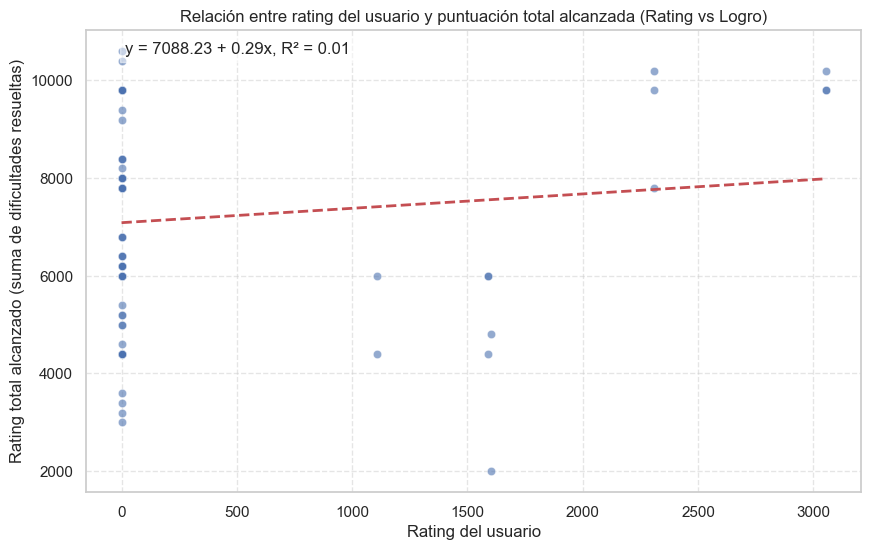

In [7]:
# 4. Análisis descriptivo y visualizaciones

# 4.1 Histograma para los tiempos de envío
plt.figure(figsize=(12, 6))
for problem in ['A', 'B', 'C']:
    col = f'relative_time_{problem}'
    if col in analysis_df.columns:
        sns.histplot(analysis_df[col].dropna(), bins=20, kde=True, label=f'Problema {problem}')

plt.title('Distribución de tiempos de envío por problema (Distribución de tiempos de envío)')
plt.xlabel('Tiempo relativo desde el inicio del concurso (segundos)')
plt.ylabel('Frecuencia')
plt.legend()
plt.savefig('histograma_tiempos_envio.png', dpi=300, bbox_inches='tight')
plt.show()

# 4.2 Kernel de densidad para ratings máximos de usuarios
plt.figure(figsize=(10, 6))
sns.kdeplot(analysis_df['max_rating'].dropna(), fill=True, color='blue')
plt.title('Distribución de ratings máximos de usuarios (Distribución de ratings máximos)')
plt.xlabel('Rating Máximo')
plt.ylabel('Densidad')
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('densidad_max_ratings.png', dpi=300, bbox_inches='tight')
plt.show()

# 4.3 Boxplots de lenguaje vs tiempo de respuesta
plt.figure(figsize=(14, 8))

# Recopilar datos de lenguaje y tiempo para todos los problemas
language_time_data = []

for problem in ['A', 'B', 'C']:
    lang_col = f'{problem}_language'
    time_col = f'time_to_answer_{problem}'
    
    if lang_col in analysis_df.columns and time_col in analysis_df.columns:
        temp_df = analysis_df[[lang_col, time_col]].dropna()
        temp_df['problem'] = problem
        temp_df.columns = ['language', 'time_to_answer', 'problem']
        language_time_data.append(temp_df)

if language_time_data:
    lang_time_df = pd.concat(language_time_data)
    
    # Filtrar para mostrar solo los 5 lenguajes más comunes
    top_languages = lang_time_df['language'].value_counts().head(5).index
    lang_time_df = lang_time_df[lang_time_df['language'].isin(top_languages)]
    
    # Crear boxplot
    sns.boxplot(x='language', y='time_to_answer', hue='problem', data=lang_time_df)
    plt.title('Tiempo para resolver problemas por lenguaje de programación (Tiempo por lenguaje)')
    plt.xlabel('Lenguaje')
    plt.ylabel('Tiempo para resolver (segundos)')
    plt.xticks(rotation=45)
    plt.legend(title='Problema')
    plt.tight_layout()
    plt.savefig('boxplot_lenguaje_tiempo.png', dpi=300, bbox_inches='tight')
    plt.show()

# 4.4 Binscatter para rating vs time_to_answer
plt.figure(figsize=(10, 6))

# Recopilar datos de rating y tiempo para todos los problemas
rating_time_data = []

for index, row in analysis_df.iterrows():
    user_rating = row['rating']
    
    for problem in ['A', 'B', 'C']:
        time_col = f'time_to_answer_{problem}'
        
        if time_col in row and not pd.isna(row[time_col]):
            rating_time_data.append({
                'rating': user_rating,
                'time_to_answer': row[time_col],
                'problem': problem
            })

rating_time_df = pd.DataFrame(rating_time_data)

if not rating_time_df.empty:
    # Filtrar valores de rating que son 0 o nulos
    rating_time_df = rating_time_df[rating_time_df['rating'] > 0]
    
    if len(rating_time_df) > 0:
        # Crear bins para rating - añadimos duplicates='drop' para manejar valores duplicados
        try:
            n_bins = min(10, len(rating_time_df['rating'].unique()))  # Ajustamos el número de bins
            rating_time_df['rating_bin'] = pd.qcut(rating_time_df['rating'], n_bins, labels=False, duplicates='drop')
            
            # Calcular promedio de tiempo por bin y problema
            binned_data = rating_time_df.groupby(['rating_bin', 'problem'])['time_to_answer'].mean().reset_index()
            
            # Calcular valor medio de rating por bin
            rating_bins = rating_time_df.groupby('rating_bin')['rating'].mean().reset_index()
            
            # Fusionar datos
            binned_data = binned_data.merge(rating_bins, on='rating_bin')
            
            # Crear gráfico
            for problem, color in zip(['A', 'B', 'C'], ['blue', 'green', 'red']):
                problem_data = binned_data[binned_data['problem'] == problem]
                if not problem_data.empty:
                    plt.scatter(problem_data['rating'], problem_data['time_to_answer'], 
                              label=f'Problema {problem}', color=color, s=80, alpha=0.7)
                    
                    # Añadir línea de tendencia si hay suficientes puntos
                    if len(problem_data) > 1:
                        z = np.polyfit(problem_data['rating'], problem_data['time_to_answer'], 1)
                        p = np.poly1d(z)
                        plt.plot(problem_data['rating'], p(problem_data['rating']), 
                                color=color, linestyle='--', alpha=0.7)
            
            plt.title('Relación entre rating del usuario y tiempo para resolver problemas (Rating vs Tiempo)')
            plt.xlabel('Rating del usuario')
            plt.ylabel('Tiempo promedio para resolver (segundos)')
            plt.legend()
            plt.grid(True, linestyle='--', alpha=0.5)
            plt.savefig('binscatter_rating_tiempo.png', dpi=300, bbox_inches='tight')
            plt.show()
        except Exception as e:
            print(f"Error en la creación del binscatter: {e}")
            # Alternativa: crear un scatter plot simple sin bins
            plt.figure(figsize=(10, 6))
            for problem, color in zip(['A', 'B', 'C'], ['blue', 'green', 'red']):
                problem_data = rating_time_df[rating_time_df['problem'] == problem]
                if not problem_data.empty:
                    plt.scatter(problem_data['rating'], problem_data['time_to_answer'], 
                              label=f'Problema {problem}', color=color, alpha=0.5)
            plt.title('Relación entre rating del usuario y tiempo para resolver problemas (Rating vs Tiempo)')
            plt.xlabel('Rating del usuario')
            plt.ylabel('Tiempo para resolver (segundos)')
            plt.legend()
            plt.grid(True, linestyle='--', alpha=0.5)
            plt.savefig('scatter_rating_tiempo.png', dpi=300, bbox_inches='tight')
            plt.show()
    else:
        print("No hay suficientes datos de rating válidos para crear el binscatter")
# 4.5 Regresión lineal para rating vs rating_achieved
plt.figure(figsize=(10, 6))

# Eliminar filas con datos faltantes
regression_df = analysis_df[['rating', 'rating_achieved']].dropna()

if not regression_df.empty:
    # Crear gráfico de dispersión
    sns.scatterplot(x='rating', y='rating_achieved', data=regression_df, alpha=0.6)
    
    # Ajustar un modelo de regresión lineal
    model = ols('rating_achieved ~ rating', data=regression_df).fit()
    
    # Imprimir resultados del modelo
    print(model.summary())
    
    # Crear valores predichos para la línea de regresión
    x_range = np.linspace(regression_df['rating'].min(), regression_df['rating'].max(), 100)
    y_pred = model.params[0] + model.params[1] * x_range
    
    # Añadir línea de regresión
    plt.plot(x_range, y_pred, 'r--', linewidth=2)
    
    # Añadir fórmula de regresión y R²
    equation = f"y = {model.params[0]:.2f} + {model.params[1]:.2f}x, R² = {model.rsquared:.2f}"
    plt.text(0.05, 0.95, equation, transform=plt.gca().transAxes, 
             bbox=dict(facecolor='white', alpha=0.5))
    
    plt.title('Relación entre rating del usuario y puntuación total alcanzada (Rating vs Logro)')
    plt.xlabel('Rating del usuario')
    plt.ylabel('Rating total alcanzado (suma de dificultades resueltas)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.savefig('regresion_rating_logro.png', dpi=300, bbox_inches='tight')
    plt.show()

In [8]:
# 5. Interpretación de los resultados

# 5.1 Resumen del Dataset
print("\nResumen del Dataset:")
print(f"Número total de participantes analizados: {len(analysis_df['author_handle'].unique())}")
print(f"Número total de concursos analizados: {len(analysis_df['contest_id'].unique())}")

print("\nEstadísticas descriptivas:")
print(analysis_df[['rating', 'max_rating', 'rating_achieved']].describe())

# 5.2 Lenguajes más utilizados
print("\nLenguajes más utilizados:")
languages = []
for problem in ['A', 'B', 'C']:
    lang_col = f'{problem}_language'
    if lang_col in analysis_df.columns:
        languages.extend(analysis_df[lang_col].dropna().tolist())

lang_counts = pd.Series(languages).value_counts().head(10)
print(lang_counts)

# 5.3 Tasa de resolución de problemas
print("\nTasa de resolución de problemas:")
for problem in ['A', 'B', 'C', 'D', 'E']:
    col = f'finished_{problem}'
    if col in analysis_df.columns:
        solve_rate = analysis_df[col].mean() * 100
        print(f"Problema {problem}: {solve_rate:.2f}%")


Resumen del Dataset:
Número total de participantes analizados: 50
Número total de concursos analizados: 3

Estadísticas descriptivas:
            rating   max_rating  rating_achieved
count   139.000000   139.000000       139.000000
mean    189.057554   195.705036      7143.884892
std     626.630208   650.014252      1933.687440
min       0.000000     0.000000      2000.000000
25%       0.000000     0.000000      6000.000000
50%       0.000000     0.000000      7800.000000
75%       0.000000     0.000000      8300.000000
max    3055.000000  3147.000000     10600.000000

Lenguajes más utilizados:
C++17 (GCC 7-32)            141
C++23 (GCC 14-64, msys2)    115
C++20 (GCC 13-64)            95
Python 3                     21
PyPy 3-64                    12
GNU C11                      10
Java 21                       3
PyPy 3                        1
Name: count, dtype: int64

Tasa de resolución de problemas:
Problema A: 100.00%
Problema B: 100.00%
Problema C: 100.00%
Problema D: 100.00%
P